In [37]:

import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import auc,classification_report, roc_auc_score, roc_curve
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.base import is_classifier
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.colors as mcolors




### Colors 

In [38]:
sns.set_theme(style="whitegrid", palette="Greys_r")
plt.rcParams["figure.figsize"] = (12, 6)   # más compactas
plt.rcParams["figure.dpi"] = 100

red_grey = mcolors.LinearSegmentedColormap.from_list(
    "RedGrey",
    ["#bfbfbf96", "#c60f0f"]  # gris → rojo
)

### Funciones 

In [39]:
def plot_macro_roc(y_test, proba, model_name="Modelo"):

    n_classes = proba.shape[1]
    y_bin = label_binarize(y_test, classes=np.arange(n_classes))

    fpr, tpr = {}, {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], proba[:, i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):  
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    plt.figure()
    sns.lineplot(x=all_fpr, y=mean_tpr, linewidth=2,
                 label=f"Macro ROC (AUC = {macro_auc:.3f})")

    sns.lineplot(x=[0,1], y=[0,1], linestyle="--", color = "#c60f0f")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Macro ROC - {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return macro_auc

In [40]:
def plot_global_roc(y_test, proba, model_name="Modelo"):

    n_classes = proba.shape[1]
    y_bin = label_binarize(y_test, classes=np.arange(n_classes))

    fpr, tpr, _ = roc_curve(y_bin.ravel(), proba.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(12,6))

    # Curva ROC
    plt.plot(fpr, tpr, linewidth=2,
             label=f"Global ROC (AUC = {roc_auc:.3f})")

    # Línea aleatoria en rojo
    plt.plot([0,1], [0,1],
             linestyle="--",
             color="#c60f0f",
             label="Random classifier")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Global ROC - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return roc_auc

In [41]:
def plot_roc_curve_multiclass(y_test, proba,
                              model_name="Modelo",
                              class_names=("Poor","Standard","Good")):

    y_test = np.array(y_test)
    n_classes = proba.shape[1]
    y_bin = label_binarize(y_test, classes=np.arange(n_classes))

    plt.figure(figsize=(12,6))

    for i, name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, linewidth=2,
                 label=f"{name} (AUC = {roc_auc:.3f})")

    # Línea aleatoria roja
    plt.plot([0,1], [0,1],
             linestyle="--",
             color="#c60f0f",
             label="Random")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [42]:

def evaluate_model_with_shap(model,X_train,y_train,X_test,y_test,model_name="Modelo",top_n=10,shap_sample=1000):

    y_proba = model.predict_proba(X_test)
    auc_score = roc_auc_score(y_test,y_proba,multi_class="ovr",average="macro")
    print(f"{model_name} AUC: {auc_score:.4f}")

    if hasattr(model,"feature_importances_"):
        imp = pd.DataFrame({"feature":X_train.columns,"importance":model.feature_importances_}).sort_values("importance")
        imp.tail(top_n).plot.barh(x="feature",y="importance",figsize=(8,6))
        plt.grid(True)
        plt.title("Model Feature Importance")
        plt.show()

    print("Calculando SHAP...")

    X_shap = X_test.sample(min(shap_sample,len(X_test)),random_state=42).astype(float)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

    shap.summary_plot(shap_values,X_shap,plot_type="bar",max_display=top_n)

    class_names=["Poor","Standard","Good"]

    for i,name in enumerate(class_names):

        fig,axes = plt.subplots(1,2,figsize=(14,5))

        plt.sca(axes[0])
        shap.summary_plot(shap_values[i],X_shap,plot_type="dot",max_display=top_n,show=False)
        axes[0].set_title(f"{name} Impact")

        plt.sca(axes[1])
        shap.summary_plot(shap_values[i],X_shap,plot_type="bar",max_display=top_n,show=False)
        axes[1].set_title(f"{name} Importance")

        plt.tight_layout()
        plt.show()

    return auc_score

In [43]:

def _normalize_shap_values(shap_values, X, class_idx=0):
    # list output (common in classifier explainers)
    if isinstance(shap_values, list):
        shap_values = shap_values[class_idx]

    shap_values = np.asarray(shap_values)

    # 3D output: (samples, features, classes)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, class_idx]

    assert shap_values.shape == X.shape, (
        f"SHAP shape {shap_values.shape} != X shape {X.shape}"
    )
    return shap_values


In [44]:
def plot_global_shap_multiclass(raw_shap, X, top_n=10,
                                class_names=("Class 0","Class 1","Class 2")):
    """
    Global SHAP importance multiclass (stacked), control total de tamaño.
    """

    # ---- Convertir a array 3D si viene como lista ----
    if isinstance(raw_shap, list):
        shap_array = np.stack(raw_shap, axis=2)  # (samples, features, classes)
    else:
        shap_array = raw_shap  # ya es 3D

    # ---- Mean absolute SHAP ----
    mean_abs = np.mean(np.abs(shap_array), axis=0)  # (features, classes)

    # ---- Ordenar por importancia total ----
    total_importance = mean_abs.sum(axis=1)
    top_idx = np.argsort(total_importance)[-top_n:]

    features = X.columns[top_idx]
    values = mean_abs[top_idx]

    # ---- Plot ----
    plt.figure(figsize=(12,6))

    bottom = np.zeros(len(top_idx))

    for i in range(values.shape[1]):
        plt.barh(features, values[:, i], left=bottom, label=class_names[i])
        bottom += values[:, i]

    plt.xlabel("mean(|SHAP value|) (average impact magnitude)")
    plt.title("Global Feature Importance (Multiclass)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    

In [45]:
def shap_multiclass_full_report(model, X,
                                class_names=("Poor","Standard","Good"),
                                top_n=10, sample_size=1000):

    X_shap = X.sample(min(sample_size, len(X)), random_state=42).astype(float)
    explainer = shap.TreeExplainer(model)
    raw_shap = explainer.shap_values(X_shap)

    for i, name in enumerate(class_names):

        shap_values = _normalize_shap_values(raw_shap, X_shap, class_idx=i)

        fig, axes = plt.subplots(
            1, 2,
            figsize=(12, 6),
            gridspec_kw={"width_ratios": [2, 1]}
        )

        fig.suptitle(f"Class: {name}", fontsize=12, fontweight="bold")

        # ---- DOT ----
        plt.sca(axes[0])
        shap.summary_plot(
            shap_values,
            X_shap,
            plot_type="dot",
            max_display=10,
            cmap=red_grey,
            show=False
        )
        axes[0].set_title("SHAP Impact", fontsize=9)

        # ---- BAR ----
        plt.sca(axes[1])
        shap.summary_plot(
            shap_values,
            X_shap,
            plot_type="bar",
            max_display=10,
            color="#6e6e6e",
            show=False
        )

        axes[1].set_yticklabels([])
        axes[1].set_ylabel("")
        axes[1].set_title("Feature Importance", fontsize=9)

        
        fig.set_size_inches(12, 6)

        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(12,6))

    plot_global_shap_multiclass(raw_shap, X_shap, top_n=top_n, class_names=class_names)

In [46]:
def plot_probability_histogram(y_test, proba,
                               model_name="Modelo",
                               class_names=("Poor","Standard","Good")):

    y_test = np.array(y_test)

    plt.figure()

    for i, name in enumerate(class_names):

        sns.histplot(
            proba[y_test == i, i],
            bins=25,
            stat="density",
            element="step",
            fill=False,
            linewidth=2,
            label=name
        )

    plt.title(f"Probability Distribution - {model_name}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [47]:
def plot_probability_density(y_test, proba,
                             model_name="Modelo",
                             class_names=("Poor","Standard","Good")):

    y_test = np.array(y_test)

    plt.figure()

    for i, name in enumerate(class_names):

        sns.kdeplot(
            proba[y_test == i, i],
            fill=True,
            alpha=0.3,
            linewidth=2,
            label=name
        )

    plt.title(f"Probability Density - {model_name}")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [48]:
def plot_xgb_importance(model, X, 
                        importance_type="gain",
                        top_n=10):

    booster = model.get_booster()
    score = booster.get_score(importance_type=importance_type)

    # Convertir a DataFrame
    imp = pd.DataFrame({
        "feature": list(score.keys()),
        "importance": list(score.values())
    })

    # Mapear nombres reales si vienen como f0,f1,...
    if all(f.startswith("f") for f in imp["feature"]):
        feature_map = {f"f{i}": col for i, col in enumerate(X.columns)}
        imp["feature"] = imp["feature"].map(feature_map)

    imp = imp.sort_values("importance").tail(top_n)

    plt.figure(figsize=(12,6))
    plt.barh(imp["feature"], imp["importance"])
    plt.xlabel(f"XGBoost Importance ({importance_type})")
    plt.title(f"Top {top_n} Features - {importance_type}")
    plt.tight_layout()
    plt.show()

---

In [61]:
df = pd.read_csv("data/clean_train.csv")

mapping = {
    "Poor": 0,
    "Standard": 1,
    "Good": 2
}

y = df["Credit_Score"].map(mapping)


X = df.drop("Credit_Score", axis=1)

X = pd.get_dummies(X, drop_first=True).astype(float)

selected_features = [
    'Outstanding_Debt',
    'Interest_Rate',
    'Delay_from_due_date',
    'Num_Credit_Card',
    'Changed_Credit_Limit',
    'Total_EMI_per_month',
    'Credit_Mix_Standard',
    'Credit_Mix_Good',
    'Payment_of_Min_Amount_Yes'
]

X = X[selected_features]

### Modelo 

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

model = XGBClassifier(
    objective="multi:softprob",   
    num_class=3,                  
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro"))


              precision    recall  f1-score   support

           0       0.77      0.75      0.76      5799
           1       0.79      0.80      0.79     10635
           2       0.71      0.71      0.71      3566

    accuracy                           0.77     20000
   macro avg       0.76      0.75      0.76     20000
weighted avg       0.77      0.77      0.77     20000

AUC: 0.8956157671153622


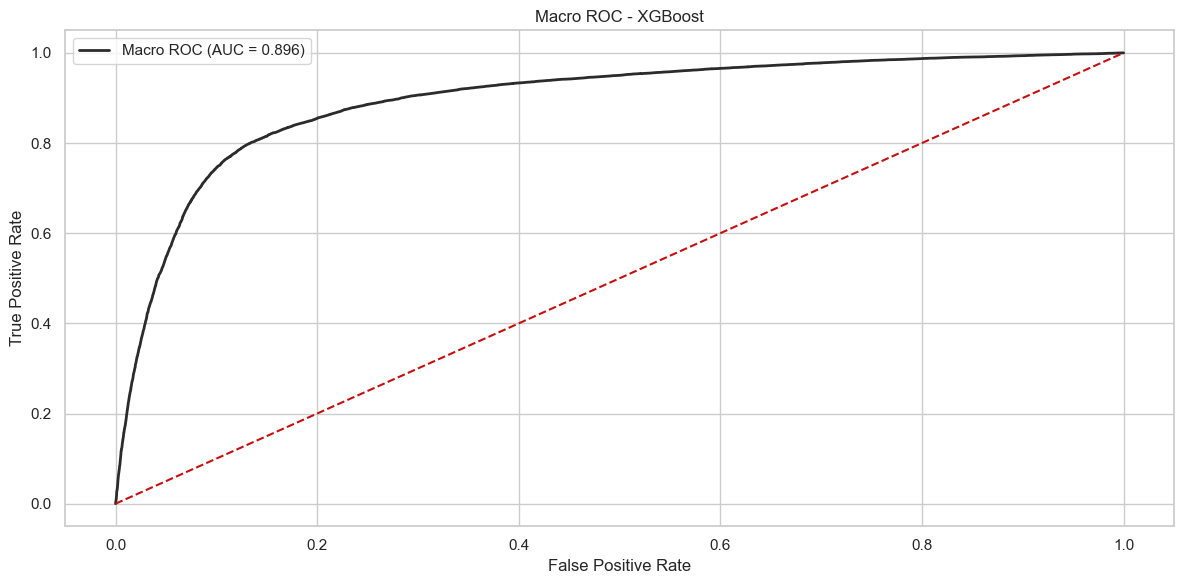

0.8956372559028607

In [51]:
plot_macro_roc(y_test, y_proba, model_name="XGBoost")

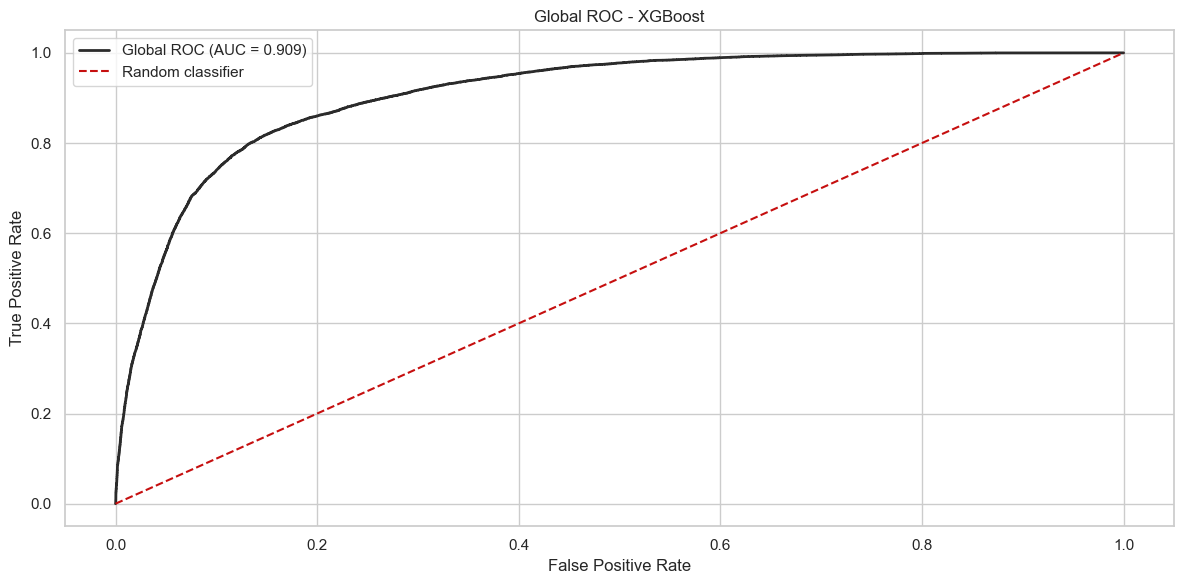

0.9094505049999999

In [52]:
plot_global_roc(y_test, y_proba, model_name="XGBoost")

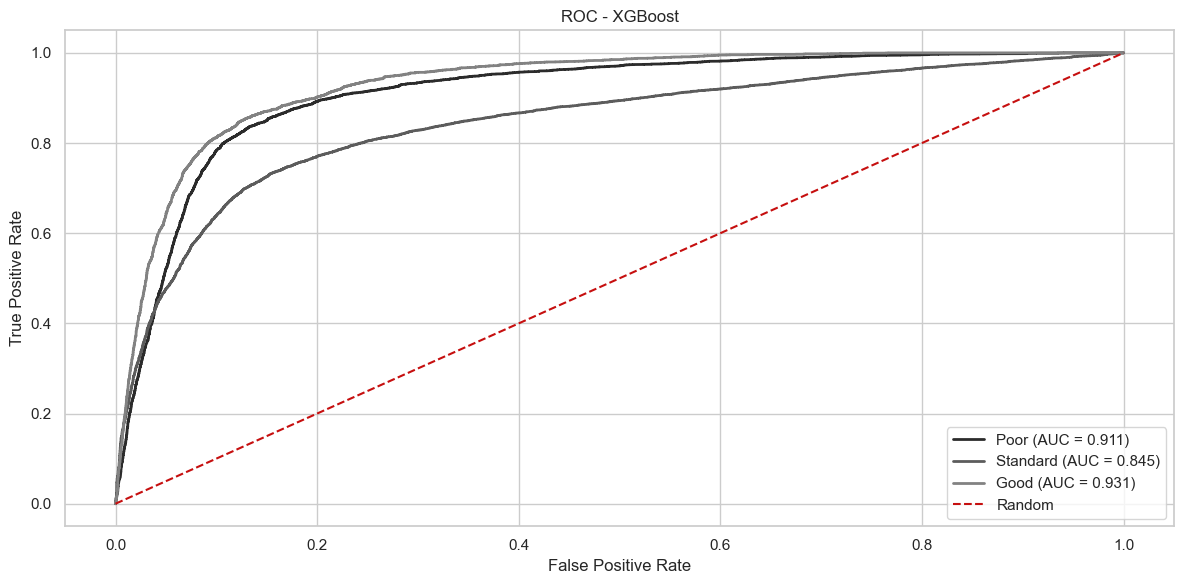

In [53]:
plot_roc_curve_multiclass(y_test, y_proba, model_name="XGBoost") 

In [54]:
explainer = shap.TreeExplainer(model)
raw_shap = explainer.shap_values(X_test)

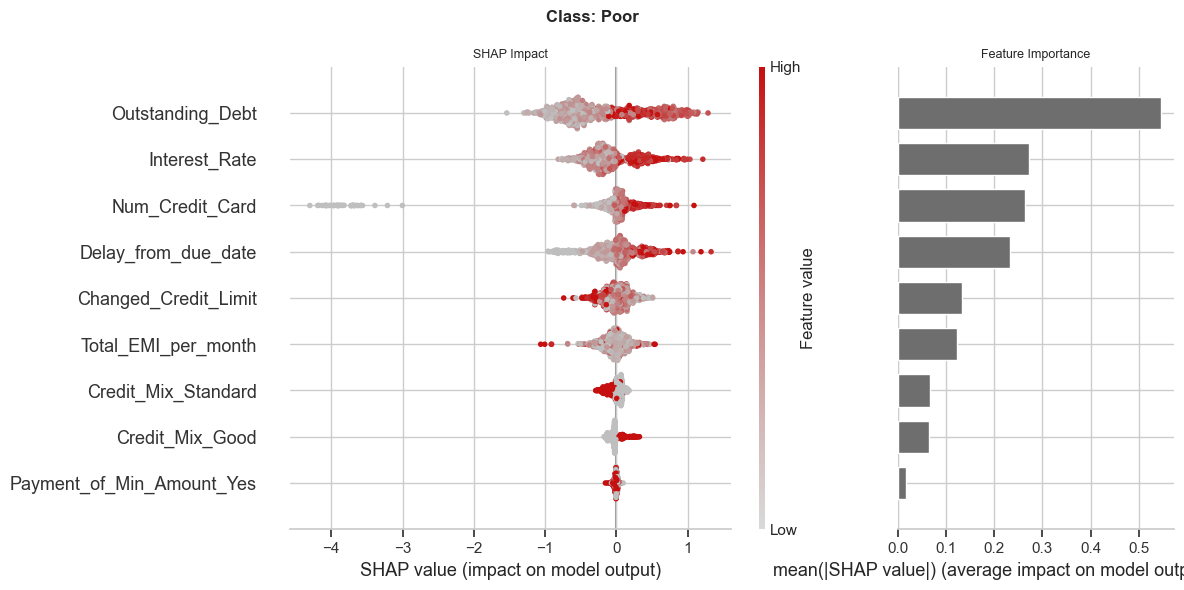

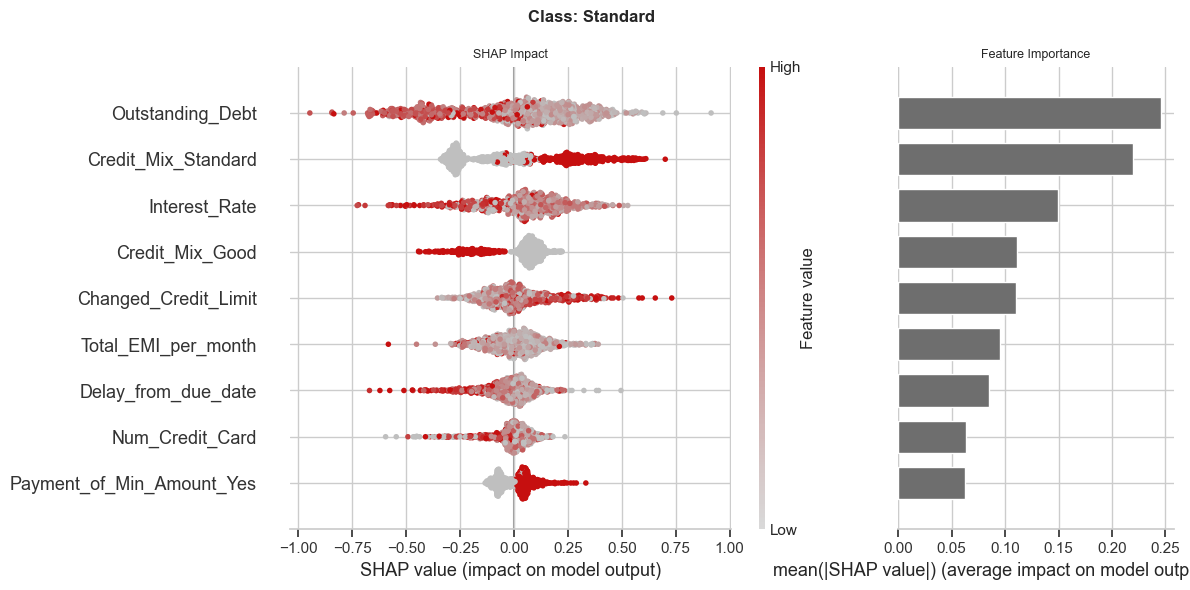

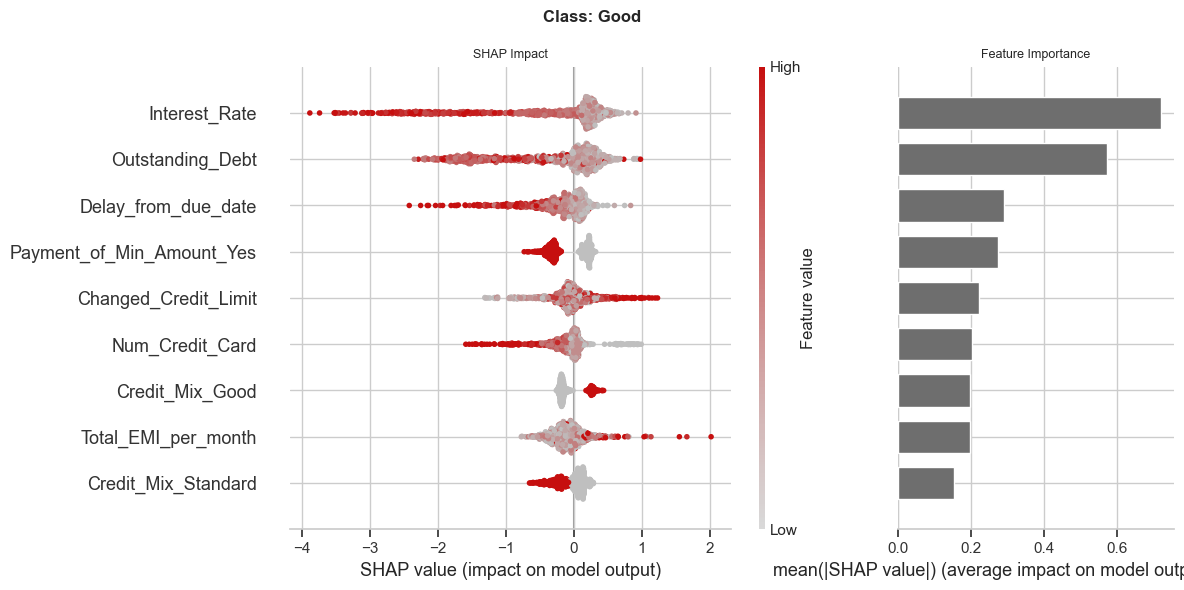

<Figure size 1200x600 with 0 Axes>

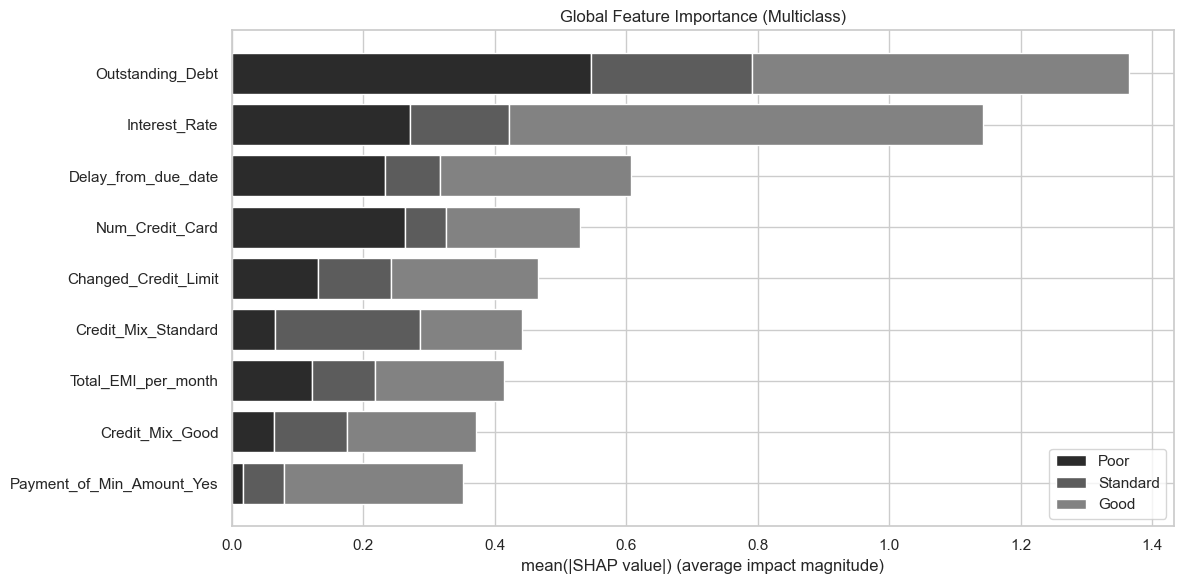

In [55]:
shap_multiclass_full_report(
    model=model,
    X=X_test,
    class_names=("Poor","Standard","Good"),
    top_n=10,
    sample_size=1000,
)

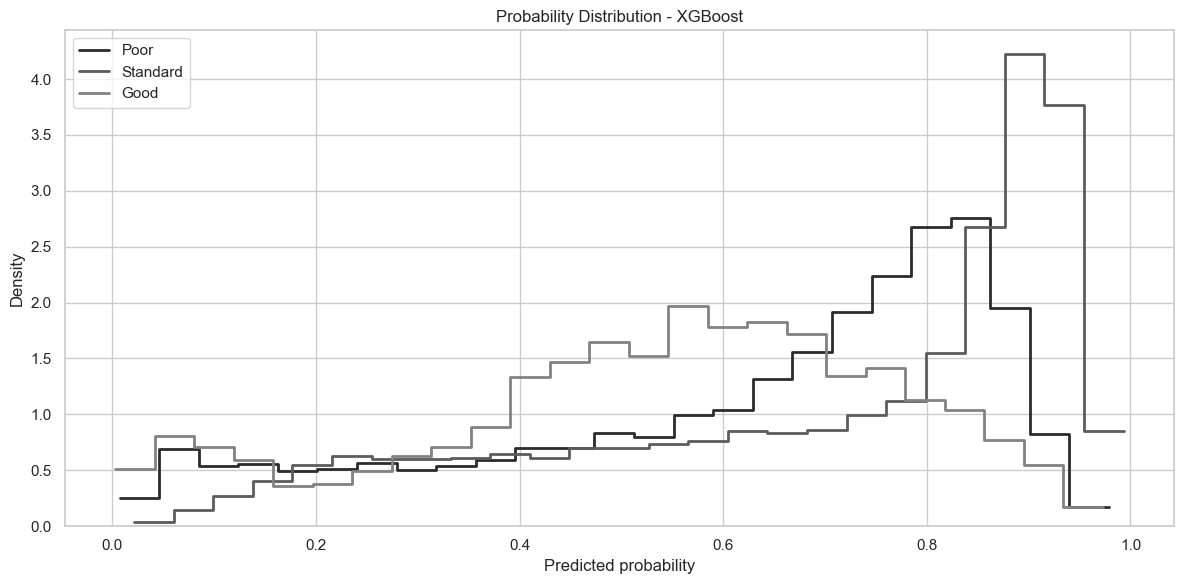

In [56]:
plot_probability_histogram(
    y_test,
    y_proba,
    model_name="XGBoost"
)

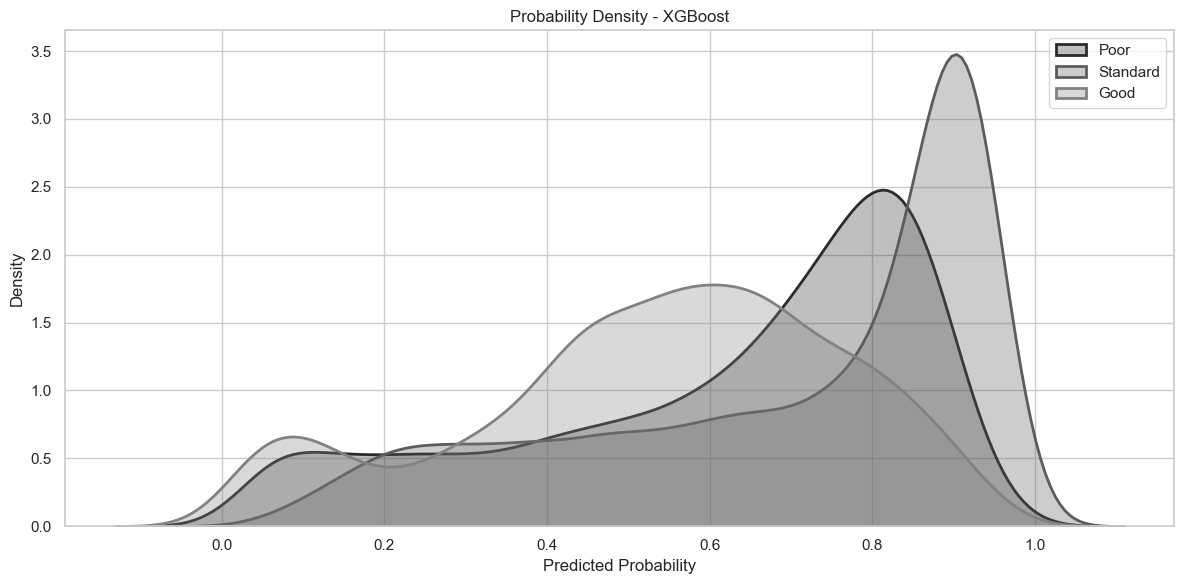

In [57]:
plot_probability_density(
    y_test,
    y_proba,
    model_name="XGBoost"
)

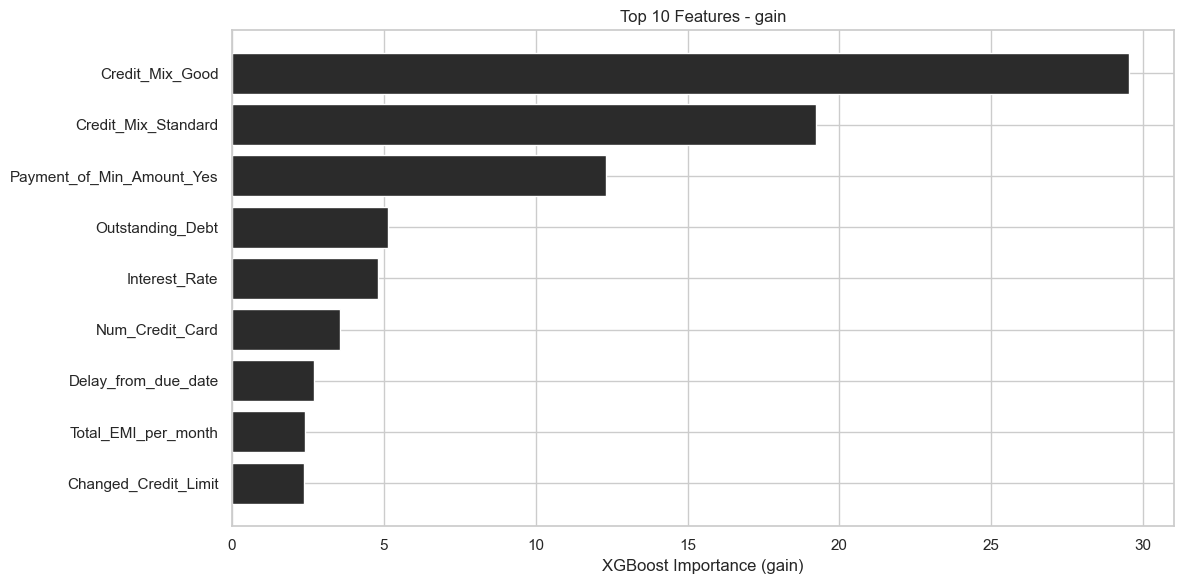

In [58]:
plot_xgb_importance(model, X_train, importance_type="gain")

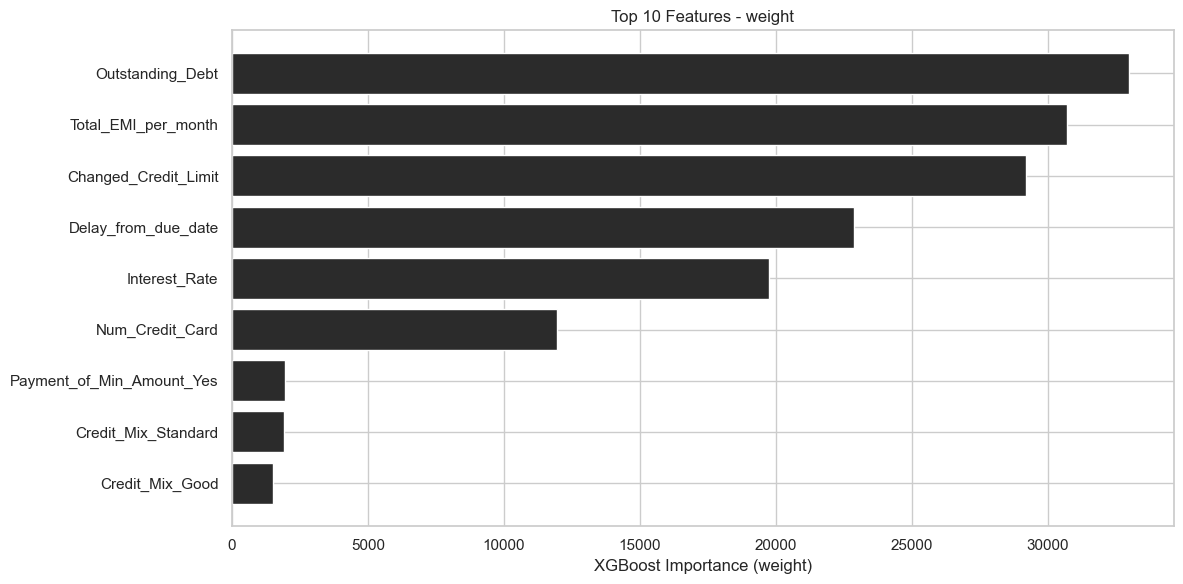

In [59]:
plot_xgb_importance(model, X_train, importance_type="weight")

In [63]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)
importance.head(10)

,feature,importance
7,Credit_Mix_Good,0.359750
6,Credit_Mix_Standard,0.234340
8,Payment_of_Min_Amount_Yes,0.150085
0,Outstanding_Debt,0.062543
1,Interest_Rate,0.058462
3,Num_Credit_Card,0.043418
2,Delay_from_due_date,0.033140
5,Total_EMI_per_month,0.029241
4,Changed_Credit_Limit,0.029021
